sns.scatterplot(data=df, x='col', y='col')             # one measurement against another

sns.histplot(data=df, x='col')                         # the distribution of one column

sns.barplot(x=series.values, y=series.index)           # a grouped Series, as bars

hue='col'                                              # works on all three

df.dropna()

df.groupby('key')['column'].agg(['count', 'mean'])

df['column'].value_counts()

df.sort_values('column', ascending=False)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = 'https://eds-217-essential-python.github.io/data/penguins.csv'
penguins = pd.read_csv(url)

### Part 1. What is in the file

In [2]:
penguins.shape

(344, 7)

In [3]:
penguins.columns

Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='object')

In [10]:
penguins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


#### 1. How many rows and columns? What are the column names, and which are numeric?

    - There are 344 rows, 7 columns, and the columns are species', 'island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex'. The ones that are numeric are bill_length_mm, bill_depth_mm, flipper_length_mm, body_mass_g



In [18]:
penguins['species'].value_counts()

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

In [19]:
penguins['island'].value_counts()

island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64

#### 2. Count the rows for each species, and separately for each island. Which species is rarest, and which island has the most birds?

    - The rarest specie is Chinstrap and the island that has the most birds is Biscoe.

In [23]:
penguins.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

#### 3. Run .isnull().sum(). Two different things are going on in that output. Say what each one probably is.

    - They were unable to record the sex for 11 inputs and then 2 penguins were missing some measurements.

In [24]:
birds = penguins.dropna()

In [25]:
birds

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


#### 4. Build a clean table called birds by dropping every row with any missing value, and report how many rows you lost. Then re-run the species counts on birds and say whether the losses fell evenly across the three species.

    - We lost 11 rows. 

In [27]:
birds['species'].isnull().sum()

0

### Part 2. Distributions

Text(0.5, 1.0, 'Penguin Flipper Length')

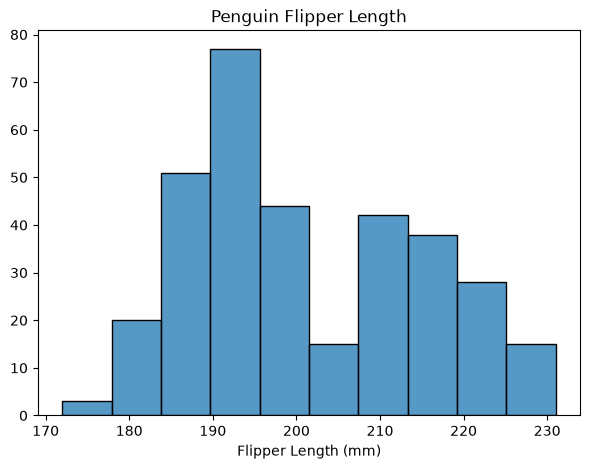

In [31]:
plt.figure(figsize = (7, 5))
sns.histplot(data = birds, x = 'flipper_length_mm')
plt.xlabel('Flipper Length (mm)')
plt.ylabel('')
plt.title('Penguin Flipper Length')


#### 5. Draw a histogram of flipper_length_mm for the whole table. Label the x-axis with units and give the figure a title. Describe the shape in one sentence

    - There is a right skew and two main peaks with a valley down the middle.

Text(0.5, 1.0, 'Penguin Flipper Length')

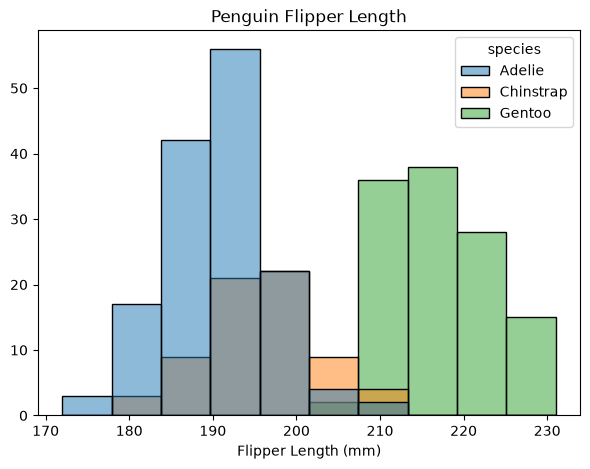

In [32]:
plt.figure(figsize = (7, 5))
sns.histplot(data = birds, x = 'flipper_length_mm', hue = 'species')
plt.xlabel('Flipper Length (mm)')
plt.ylabel('')
plt.title('Penguin Flipper Length')

#### 6. Draw it again, split by species. In a markdown cell, say what the two humps in question 5 turned out to be, and whether “the average penguin has a flipper of about 201 mm” is a useful sentence.

    - The humps were the result of two different penguins species. To generalize that the average penguin flipper length is 201 mm would be misleading because it is only for Adelle penguins. That distinction should be made.

In [34]:
birds

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


Text(0, 0.5, '')

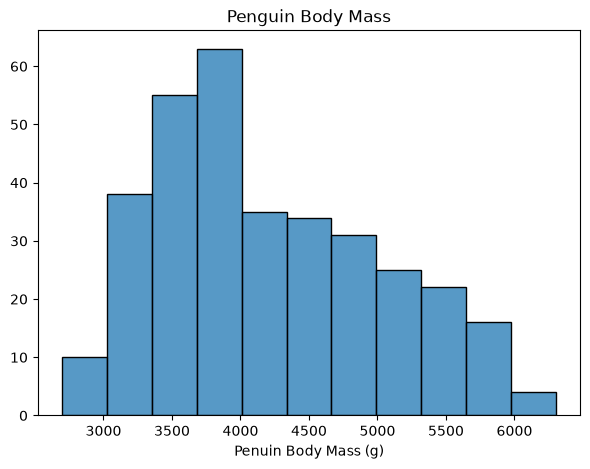

In [35]:
plt.figure(figsize = (7, 5))

sns.histplot(data = birds, x = 'body_mass_g')
plt.title('Penguin Body Mass')
plt.xlabel('Penuin Body Mass (g)')
plt.ylabel('')


Text(0, 0.5, '')

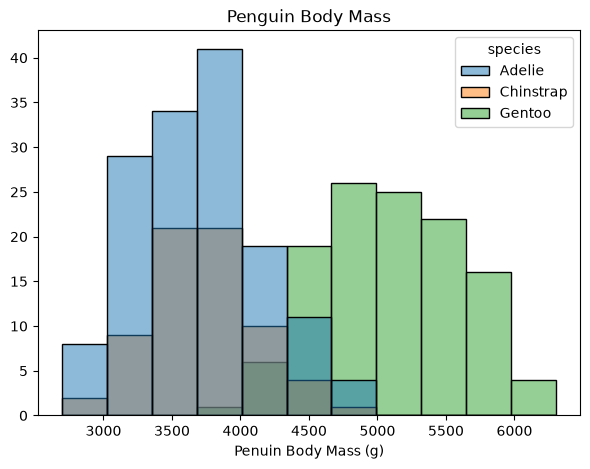

In [36]:
plt.figure(figsize = (7, 5))

sns.histplot(data = birds, x = 'body_mass_g', hue = 'species')
plt.title('Penguin Body Mass')
plt.xlabel('Penuin Body Mass (g)')
plt.ylabel('')

#### 7. Pick one of bill_length_mm, bill_depth_mm or body_mass_g and do the same pair of figures for it. Does that measurement separate the species as cleanly as flipper length does?

    - Yes it does. There is a clear distinction that different specie of penguins are larger than others.

### Part 3. Relationships

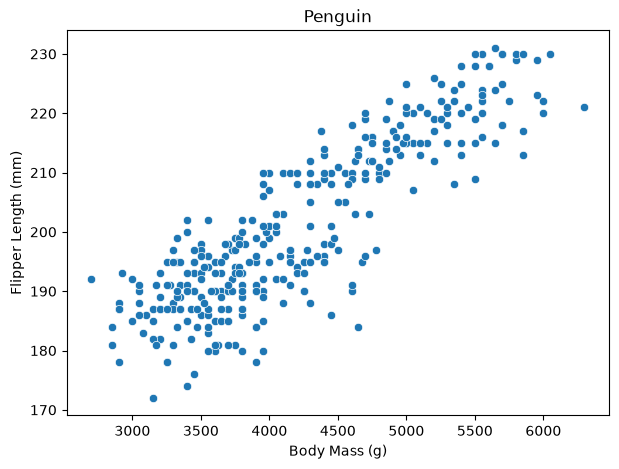

In [39]:
plt.figure(figsize = (7, 5))

sns.scatterplot(data = birds, x = 'body_mass_g', y = 'flipper_length_mm')
plt.xlabel('Body Mass (g)')
plt.ylabel('Flipper Length (mm)')
plt.title('Penguin')
plt.show()


#### 8. Draw a scatter plot of body_mass_g against flipper_length_mm, with flipper length across the bottom. Label both axes and title it. Describe the relationship in one sentence

    - There seems to be a positive trend where as penguins weigh more, they will have longer flippers.

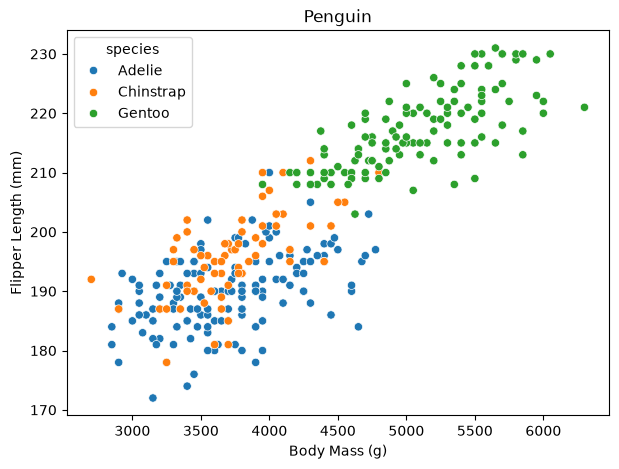

In [40]:
plt.figure(figsize = (7, 5))

sns.scatterplot(data = birds, x = 'body_mass_g', y = 'flipper_length_mm', hue = 'species')
plt.xlabel('Body Mass (g)')
plt.ylabel('Flipper Length (mm)')
plt.title('Penguin')
plt.show()

#### 9. Draw the same figure with hue='species'. Does adding the species change what you would say about the relationship, or just make it prettier? One sentence.

    - Although it does make it prettier, it adds a key distinction between which penguin species tend to be larger than the others.

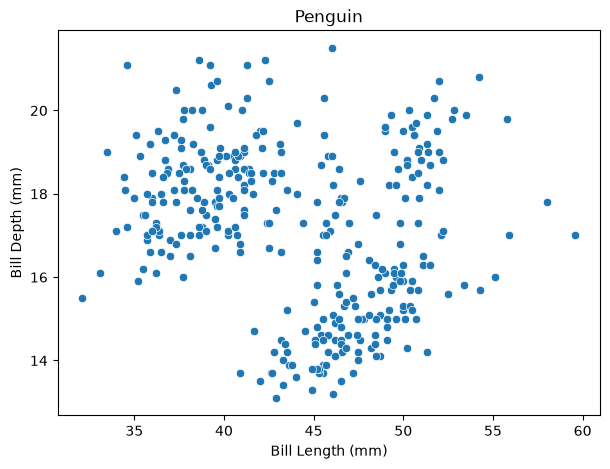

In [42]:
plt.figure(figsize = (7, 5))

sns.scatterplot(data = birds, x = 'bill_length_mm', y = 'bill_depth_mm')
plt.xlabel('Bill Length (mm)')
plt.ylabel('Bill Depth (mm)')
plt.title('Penguin')
plt.show()

#### 10.Now a different pair of columns. Draw a scatter plot of bill_depth_mm against bill_length_mm, with bill length across the bottom, and no hue=. Label it.

    - As a penguins bill length gets longer (mm) than the bill depth (mm) gets smaller. There seems to be an conflicting trend that some would not expect, likely due to the anatomy of shorter bills being deeper.

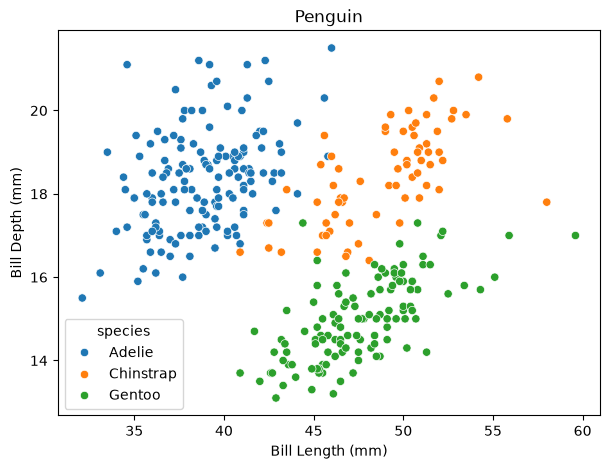

In [43]:
plt.figure(figsize = (7, 5))

sns.scatterplot(data = birds, x = 'bill_length_mm', y = 'bill_depth_mm', hue = 'species')
plt.xlabel('Bill Length (mm)')
plt.ylabel('Bill Depth (mm)')
plt.title('Penguin')
plt.show()

#### 11. Draw it once more with hue='species'.

    - yes

#### 12. Read your answer to question 10 back, and then look at question 11. Within each of the three species, longer bills go with deeper bills. Across all three together, longer bills go with shallower ones.

In a markdown cell of four or five sentences: explain how both of those can be true at once. Your explanation should mention where the three species sit relative to each other, and it should not use the word “wrong” about either figure

    - Both of these can be true at once becaue on genralizes all of the species together while the other one shows a distinction between the species. Without the hue, a lot of misleading claims can be made because with the three species being grouped together it leads to a different trend. Once you apply the hue function you can see the trend for each speice.

### Part 4. 

In [59]:
mean_body = birds.groupby('species')['body_mass_g'].mean().sort_values(ascending = False)

In [60]:
mean_body

species
Gentoo       5092.436975
Chinstrap    3733.088235
Adelie       3706.164384
Name: body_mass_g, dtype: float64

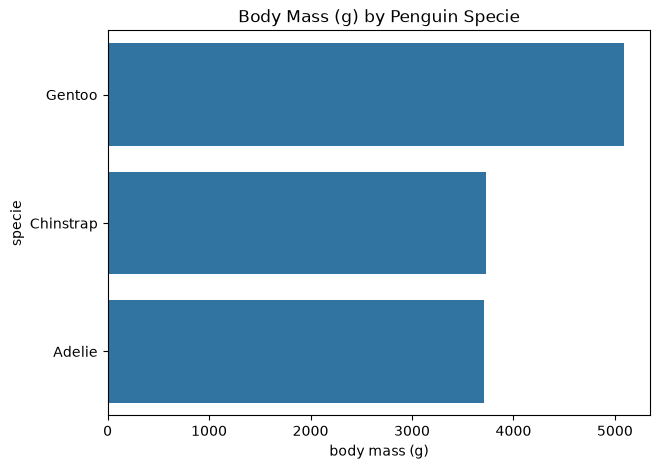

In [62]:
plt.figure(figsize = (7, 5))

sns.barplot(x = mean_body.values, y = mean_body.index)

plt.xlabel('body mass (g)')
plt.ylabel('specie')
plt.title('Body Mass (g) by Penguin Specie')
plt.show()

#### 13. Build a Series of mean body_mass_g by species, sorted from heaviest to lightest, and draw it as horizontal bars using the .values and .index idiom. Label both axes and title it.

    - Yes

#### 14. Two of those three bars are nearly the same height. Look back at your figure from question 11. In one sentence: would you say those two species are similar birds?

    - I would not say that these two species are similar birds.

           count    mean
species                 
Adelie       146  3706.2
Chinstrap     68  3733.1
Gentoo       119  5092.4


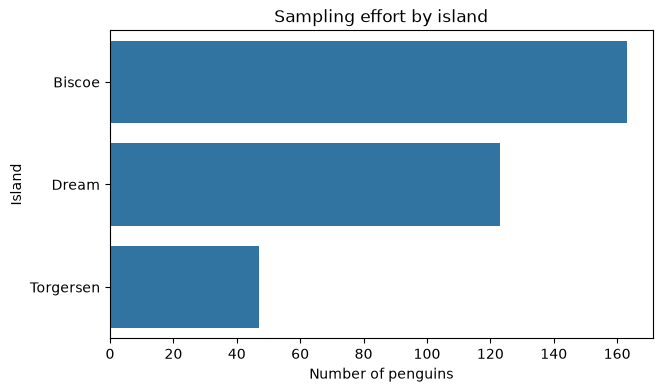

island
Biscoe       163
Dream        123
Torgersen     47
Name: count, dtype: int64


In [67]:
print(birds.groupby('species')['body_mass_g'].agg(['count', 'mean']).round(1))

island_counts = birds['island'].value_counts()

plt.figure(figsize=(7, 4))
sns.barplot(x=island_counts.values, y=island_counts.index)
plt.xlabel('Number of penguins')
plt.ylabel('Island')
plt.title('Sampling effort by island')
plt.show()

# The figure shows the imbalance. The counts name it.
print(birds['island'].value_counts())

#### 15. Run .agg(['count', 'mean']) on the same grouping and print it. Then build a Series of the number of birds on each island with .value_counts(), and draw that as horizontal bars too.

    - yes

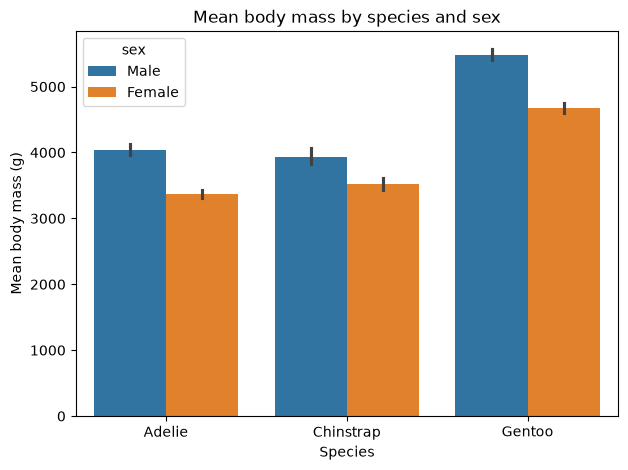

In [68]:
plt.figure(figsize=(7, 5))
sns.barplot(data=birds, x='species', y='body_mass_g', hue='sex')
plt.xlabel('Species')
plt.ylabel('Mean body mass (g)')
plt.title('Mean body mass by species and sex')
plt.show()

#### 16. Draw a bar chart of mean body_mass_g by species, split by sex. The data= form is easier here, because you want two bars per species: sns.barplot(data=birds, x='species', y='body_mass_g', hue='sex').



In [69]:
birds.pivot_table(index='species', columns='island', values='body_mass_g', aggfunc='count')

island,Biscoe,Dream,Torgersen
species,,,
Adelie,44.0,55.0,47.0
Chinstrap,NaN,68.0,NaN
Gentoo,119.0,NaN,NaN


In [70]:
adelie = birds[birds['species'] == 'Adelie']
adelie.groupby('island')['body_mass_g'].agg(['count', 'mean']).round(1)

,count,mean
island,,
Biscoe,44,3709.7
Dream,55,3701.4
Torgersen,47,3708.5


#### 17. This is the last task, and it is a bit of a trap (sorry!). Build a wide table with species down the rows, island across the columns, and a count of body_mass_g in the cells. You built the pivot pattern yesterday morning; add aggfunc='count' to it.

    - yes